Importaciones y Configuración Inicial

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm

# Importa tus clases (ajusta la ruta según la estructura de tus carpetas)
from connect4.connect_state import ConnectState
# Asumimos que guardaste el agente modular en un archivo llamado mcts_agent.py
from mcts_agent import MCTSAgent 

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

El Entorno de Pruebas (Arena)

Esta celda contiene la lógica para enfrentar a dos agentes.

Nota técnica: Para recolectar las estadísticas de simulaciones sin romper la firma de tu función act(self, s) -> int, te recomiendo que dentro de tu clase MCTSAgent, guardes el conteo de simulaciones del último turno en una variable de instancia (ej. self.last_simulations_count = simulations_count justo antes del return action). El código de abajo asume que hiciste ese pequeñísimo cambio.

In [3]:
def play_match(agent1, agent2, time_limit=5.0):
    """
    Ejecuta una partida entre agent1 (Fichas 1) y agent2 (Fichas -1).
    Retorna el ganador y un diccionario con las métricas de la partida.
    """
    state = ConnectState()
    agent1.mount(timeout=time_limit)
    agent2.mount(timeout=time_limit)
    
    # Recolectores de métricas
    metrics = {
        'a1_time_per_turn': [], 'a2_time_per_turn': [],
        'a1_sims_per_turn': [], 'a2_sims_per_turn': [],
        'turns_played': 0
    }
    
    while not state.is_final():
        if state.player == 1:
            start_t = time.time()
            action = agent1.act(state.board)
            metrics['a1_time_per_turn'].append(time.time() - start_t)
            # Asegúrate de haber añadido self.last_simulations_count a tu agente
            metrics['a1_sims_per_turn'].append(getattr(agent1, 'last_simulations_count', 0))
        else:
            start_t = time.time()
            action = agent2.act(state.board)
            metrics['a2_time_per_turn'].append(time.time() - start_t)
            metrics['a2_sims_per_turn'].append(getattr(agent2, 'last_simulations_count', 0))
            
        state = state.transition(action)
        metrics['turns_played'] += 1
        
    return state.get_winner(), metrics

def run_tournament(agent1_name, agent1, agent2_name, agent2, games=10, time_limit=5.0):
    """
    Juega N partidas, alternando quién empieza primero para evitar el sesgo de salida.
    """
    results = []
    
    print(f"--- Iniciando Torneo: {agent1_name} vs {agent2_name} ({games} partidas) ---")
    for i in tqdm(range(games)):
        # Alternar quién empieza
        if i % 2 == 0:
            winner, metrics = play_match(agent1, agent2, time_limit)
            a1_id, a2_id = 1, -1
        else:
            winner, metrics = play_match(agent2, agent1, time_limit)
            # Invertimos los IDs porque el Agente 2 jugó como el Jugador 1
            a1_id, a2_id = -1, 1 
            # Intercambiamos las métricas para mantener la consistencia
            metrics['a1_time_per_turn'], metrics['a2_time_per_turn'] = metrics['a2_time_per_turn'], metrics['a1_time_per_turn']
            metrics['a1_sims_per_turn'], metrics['a2_sims_per_turn'] = metrics['a2_sims_per_turn'], metrics['a1_sims_per_turn']

        # Determinar resultado desde la perspectiva del Agente 1
        if winner == a1_id:
            res = 'Victoria'
        elif winner == a2_id:
            res = 'Derrota'
        else:
            res = 'Empate'
            
        results.append({
            'Game': i + 1,
            'Agent1': agent1_name,
            'Agent2': agent2_name,
            'Started_First': agent1_name if i % 2 == 0 else agent2_name,
            'Result': res,
            'A1_Avg_Time': np.mean(metrics['a1_time_per_turn']),
            'A2_Avg_Time': np.mean(metrics['a2_time_per_turn']),
            'A1_Avg_Sims': np.mean(metrics['a1_sims_per_turn']),
            'A2_Avg_Sims': np.mean(metrics['a2_sims_per_turn']),
            'Total_Turns': metrics['turns_played']
        })
        
    return pd.DataFrame(results)




Ejecución de Experimentos (Ablation Study)

Aquí definimos a los contrincantes encendiendo y apagando los interruptores del código modular. Empezaremos con partidas rápidas (ej. 1 segundo por turno máximo) para acelerar la recolección de datos.

In [4]:
# Definición de agentes
agente_base = MCTSAgent(config={'heuristic': False, 'reuse_tree': False, 'prog_bias': False})
agente_heuristico = MCTSAgent(config={'heuristic': True, 'reuse_tree': False, 'prog_bias': False})
agente_memoria = MCTSAgent(config={'heuristic': False, 'reuse_tree': True, 'prog_bias': False})
agente_sesgo = MCTSAgent(config={'heuristic': False, 'reuse_tree': False, 'prog_bias': True})
agente_heuristico_memoria = MCTSAgent(config={'heuristic': True, 'reuse_tree': True, 'prog_bias': False})
agente_memoria_sesgo = MCTSAgent(config={'heuristic': False, 'reuse_tree': True, 'prog_bias': True})
agente_heuristico_sesgo = MCTSAgent(config={'heuristic': True, 'reuse_tree': False, 'prog_bias': True})
agente_completo = MCTSAgent(config={'heuristic': True, 'reuse_tree': True, 'prog_bias': True})


# 1. Base vs Heurística (Para probar si la calidad importa más que la cantidad)
df_exp1 = run_tournament("Base", agente_base, "Heurístico", agente_heuristico, games=5, time_limit=10.0)

# 2. Heurístico vs Memoria (Para probar el impacto de la Memoria y el Sesgo)
df_exp2 = run_tournament("Heurístico", agente_heuristico, "Memoria", agente_memoria, games=5, time_limit=10.0)

# 3. Memoria vs Sesgo (Para probar el impacto de la Memoria y el Sesgo)
df_exp3 = run_tournament("Memoria", agente_memoria, "Sesgo", agente_sesgo, games=5, time_limit=10.0)

# 4. Heurístico vs Sesgo (Para probar el impacto de la Memoria y el Sesgo)
df_exp4 = run_tournament("Heurístico", agente_heuristico, "Sesgo", agente_sesgo, games=5, time_limit=10.0)

# 5. Heurístico vs Completo (Para probar el impacto de la Memoria y el Sesgo)
df_exp5 = run_tournament("Heurístico", agente_heuristico, "Completo (All Toggles)", agente_completo, games=5, time_limit=10.0)



# Consolidar datos
df_all = pd.concat([df_exp1, df_exp2, df_exp3, df_exp4, df_exp5], ignore_index=True)
display(df_all.head())




--- Iniciando Torneo: Base vs Heurístico (5 partidas) ---


100%|██████████| 5/5 [05:01<00:00, 60.31s/it]


--- Iniciando Torneo: Heurístico vs Memoria (5 partidas) ---


100%|██████████| 5/5 [05:54<00:00, 71.00s/it]


--- Iniciando Torneo: Memoria vs Sesgo (5 partidas) ---


...

--- Iniciando Torneo: Heurístico vs Sesgo (5 partidas) ---


100%|██████████| 5/5 [06:27<00:00, 77.57s/it] 


--- Iniciando Torneo: Heurístico vs Completo (All Toggles) (5 partidas) ---


100%|██████████| 5/5 [04:48<00:00, 57.70s/it]


,Game,Agent1,Agent2,Started_First,Result,A1_Avg_Time,A2_Avg_Time,A1_Avg_Sims,A2_Avg_Sims,Total_Turns
0,1,Base,Heurístico,Base,Derrota,2.786609,2.788660,1760.437500,889.294118,33
1,2,Base,Heurístico,Heurístico,Derrota,2.787073,2.795246,1227.777778,200.888889,18
2,3,Base,Heurístico,Base,Victoria,2.789244,2.846438,1114.750000,55.750000,8
3,4,Base,Heurístico,Heurístico,Derrota,2.786853,2.793979,1010.083333,249.250000,24
4,5,Base,Heurístico,Base,Derrota,2.788043,2.793911,1074.000000,380.692308,25


In [5]:
display(df_all.groupby(['Agent1', 'Agent2'])['Result'].value_counts(normalize=True).unstack().fillna(0))

Result                             Derrota  Empate  Victoria
Agent1     Agent2                                           
Base       Heurístico                  0.8     0.0       0.2
Heurístico Completo (All Toggles)      0.6     0.0       0.4
           Memoria                     0.6     0.0       0.4
           Sesgo                       0.6     0.0       0.4
Memoria    Sesgo                       0.4     0.4       0.2

Visualización 1 - Tasa de Victorias (Win Rate)

El dato más importante. ¿Quién gana más?

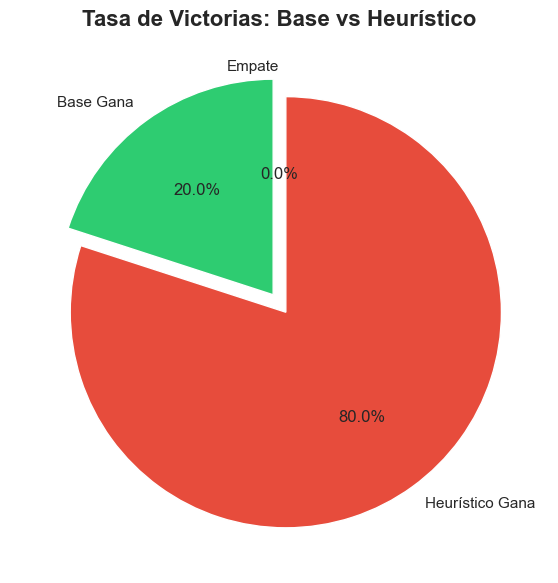

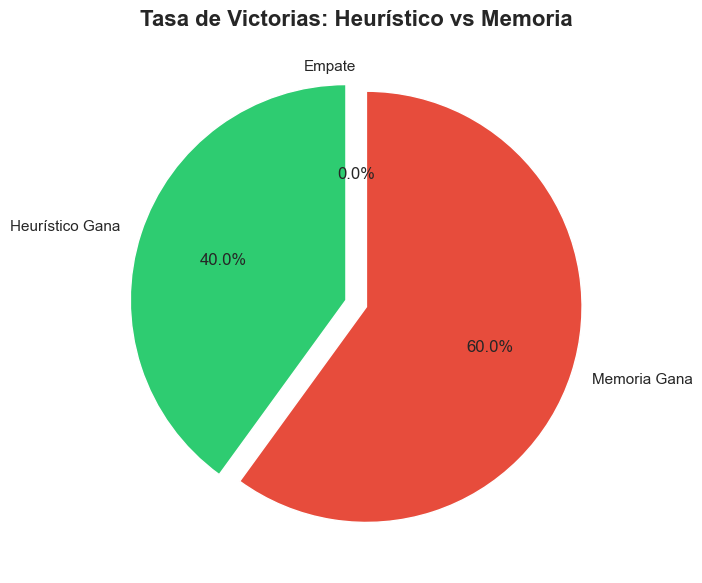

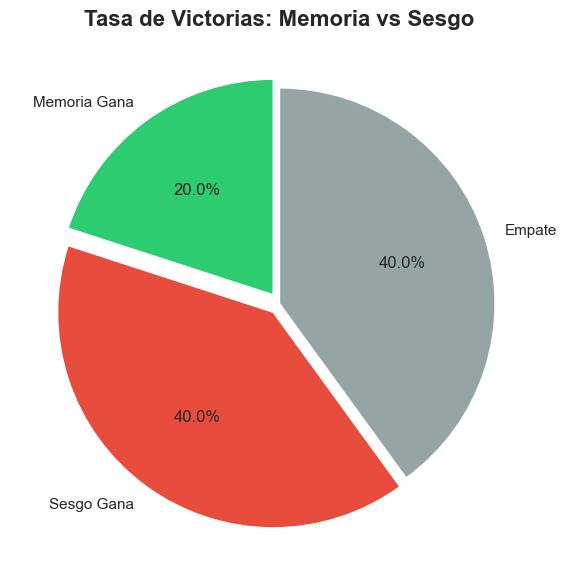

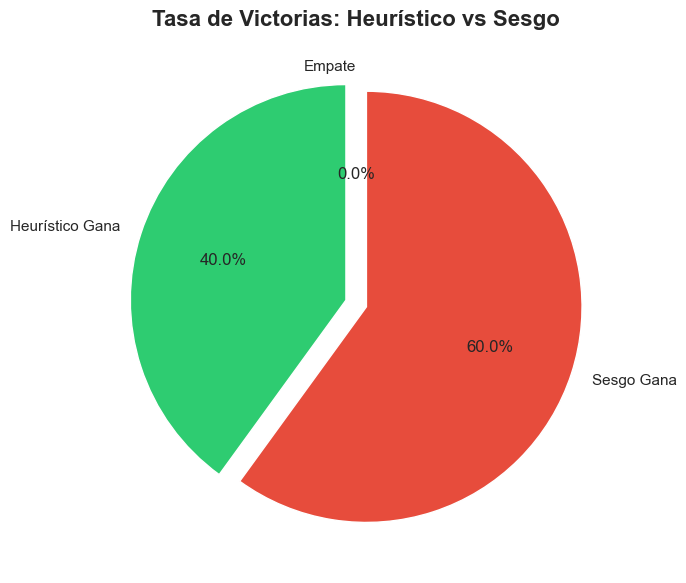

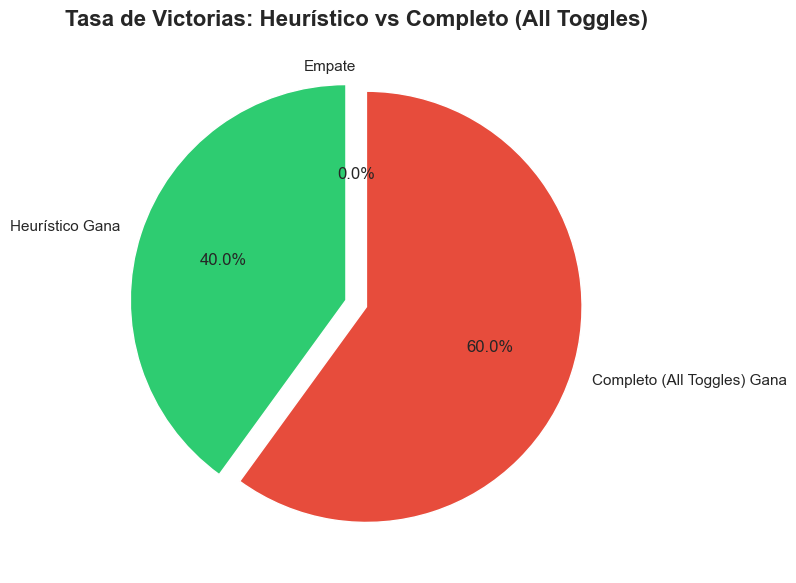

In [6]:
def plot_winrate(df, agent1_name, agent2_name):
    subset = df[(df['Agent1'] == agent1_name) & (df['Agent2'] == agent2_name)]
    
    # Contar resultados
    counts = subset['Result'].value_counts()
    
    # Asegurar que todas las categorías existan
    for cat in ['Victoria', 'Derrota', 'Empate']:
        if cat not in counts:
            counts[cat] = 0
            
    labels = [f'{agent1_name} Gana', f'{agent2_name} Gana', 'Empate']
    sizes = [counts['Victoria'], counts['Derrota'], counts['Empate']]
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']
    
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0))
    plt.title(f'Tasa de Victorias: {agent1_name} vs {agent2_name}', fontsize=16, fontweight='bold')
    plt.show()

plot_winrate(df_all, "Base", "Heurístico")
plot_winrate(df_all, "Heurístico", "Memoria")
plot_winrate(df_all, "Memoria", "Sesgo")
plot_winrate(df_all, "Heurístico", "Sesgo")
plot_winrate(df_all, "Heurístico", "Completo (All Toggles)")

Visualización 2 - Rendimiento Computacional (Trade-offs)

La heurística hace que el agente piense "mejor", pero simule "menos". La reutilización del árbol debería aumentar drásticamente el número de simulaciones aparentes. Esta gráfica demuestra este fenómeno.

C:\Users\Diego Escalante\AppData\Local\Temp\ipykernel_6892\2187941155.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_sims, x='Agent_Type', y='Avg_Simulations', palette='Set2')


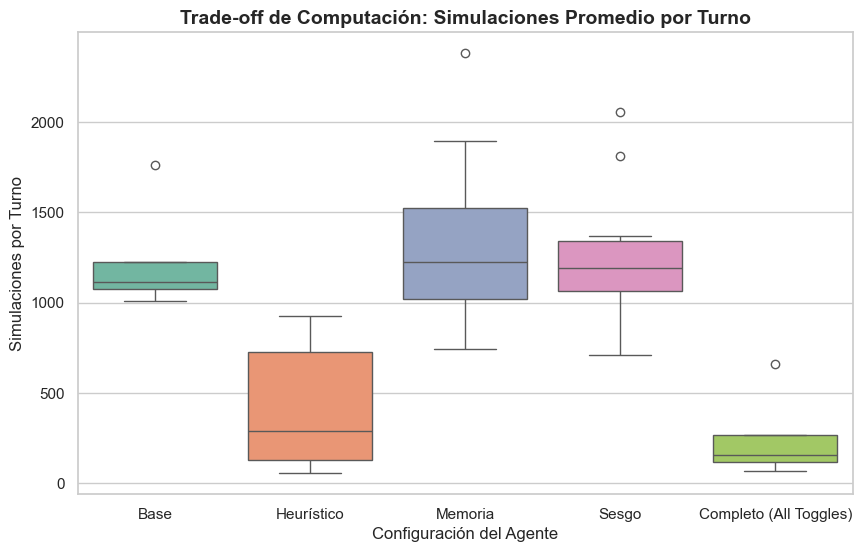

In [ ]:
def plot_simulation_tradeoff(df):
    # Preparamos los datos en formato "largo" para Seaborn
    melted_sims = pd.DataFrame(columns=['Agent_Type', 'Avg_Simulations'])
    
    for idx, row in df.iterrows():
        melted_sims.loc[len(melted_sims)] = [row['Agent1'], row['A1_Avg_Sims']]
        melted_sims.loc[len(melted_sims)] = [row['Agent2'], row['A2_Avg_Sims']]
        
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=melted_sims, x='Agent_Type', y='Avg_Simulations', palette='Set2')
    plt.title('Trade-off de Computación: Simulaciones Promedio por Turno', fontsize=14, fontweight='bold')
    plt.ylabel('Simulaciones por Turno')
    plt.xlabel('Configuración del Agente')
    # plt.yscale('log') # Escala logarítmica si las diferencias son gigantes (ej. con Reuse Tree)
    plt.show()

plot_simulation_tradeoff(df_all)